In [1]:
# import necessary libraries
import torch
from ultralytics import YOLO
# opencv, matplotlib, pil
import cv2
import matplotlib.pyplot as plt
from PIL import Image

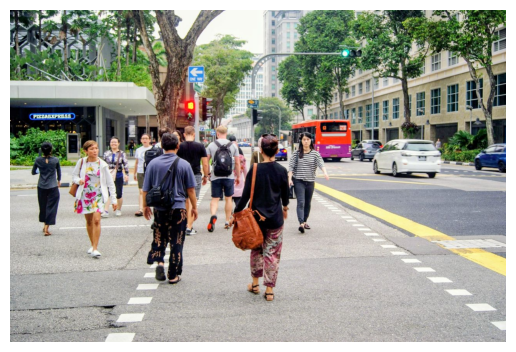

In [4]:
# Load Image 
image_path = './images/image-1.jpg'

img = Image.open(image_path)
# img.show()

plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
# Load YOLO Model
model = YOLO('yolo26n.pt')
# Understand model parameters and config
model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.2 GFLOPs


(260, 2572280, 0, 6.2396672)

In [9]:
# Pass image through YOLO model for object detection
results = model(image_path)
results[0].show()


image 1/1 d:\vedicskill\courses\yolo_upgrade\Notes\custom-yolo-train\2-ultralytics-yolo\images\image-1.jpg: 448x640 11 persons, 3 cars, 1 bus, 2 traffic lights, 2 backpacks, 2 handbags, 107.5ms
Speed: 5.4ms preprocess, 107.5ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)


In [17]:
# display object keys
label_dict = results[0].names
# extract only label names
label_names = list(label_dict.values())
print(label_names)

['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [19]:
print(results[0].boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 2.,  0.,  0.,  0.,  5.,  0.,  0.,  2., 24.,  0.,  0.,  2., 26.,  9.,  9.,  0.,  0., 24.,  0.,  0., 26.])
conf: tensor([0.8566, 0.8508, 0.8473, 0.8464, 0.8342, 0.8302, 0.8201, 0.8140, 0.7403, 0.7392, 0.7110, 0.6911, 0.6491, 0.6421, 0.5577, 0.4645, 0.3442, 0.3236, 0.3222, 0.3202, 0.3182])
data: tensor([[9.3603e+02, 3.3197e+02, 1.1128e+03, 4.3451e+02, 8.5659e-01, 2.0000e+00],
        [5.7609e+02, 3.1859e+02, 7.2751e+02, 7.5209e+02, 8.5082e-01, 0.0000e+00],
        [5.5462e+01, 3.4129e+02, 1.3493e+02, 5.8469e+02, 8.4733e-01, 0.0000e+00],
        [3.4073e+02, 3.1382e+02, 4.8815e+02, 7.0736e+02, 8.4644e-01, 0.0000e+00],
        [7.2602e+02, 2.8135e+02, 8.8294e+02, 3.9031e+02, 8.3425e-01, 5.0000e+00],
        [7.2408e+02, 3.2420e+02, 8.2292e+02, 5.7602e+02, 8.3015e-01, 0.0000e+00],
        [1.4986e+02, 3.3307e+02, 2.7430e+02, 6.4163e+02, 8.2007e-01, 0.0000e+00],
        [1.1982e+03, 3.4484e+02, 1.2793e+03, 4.1798e+02, 8.1

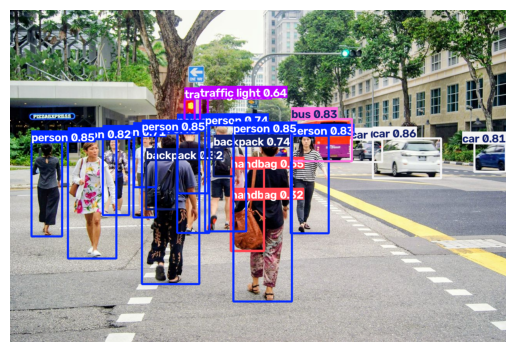

In [20]:
# Get output as NumPy Array
annotated = results[0].plot()  # Get output in BGR format as a NumPy array

# display output using Matplotlib
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
plt.imshow(annotated_rgb)
plt.axis('off')
plt.show()
